# BERT: Bidirectional Encoder Representations from Transformers

## 1. Introduction
BERT (Bidirectional Encoder Representations from Transformers) is a **Transformer-based** deep learning model designed for **natural language processing (NLP)** tasks. Unlike traditional models that process text in a left-to-right or right-to-left manner, BERT is **bidirectional**, allowing it to understand the full context of a word by analyzing both its left and right surroundings.

## 2. Architecture
BERT’s model architecture consists of multiple layers of **bidirectional Transformer encoders**. The key parameters of BERT’s architecture include:

- **L**: Number of Transformer layers (i.e., blocks)
- **H**: Hidden size (dimension of the embedding layer and output vectors per token per encoder block)
- **A**: Number of self-attention heads

### Two Standard Model Sizes:
| Model       | L (Layers) | H (Hidden Size) | A (Attention Heads) | Total Parameters |
|------------|------------|---------------|-----------------|-----------------|
| **BERTBASE**  | 12         | 768           | 12              | 110M            |
| **BERTLARGE** | 24         | 1024          | 16              | 340M            |

- **Maximum input sequence length**: **512 tokens** for both BERTBASE and BERTLARGE. The limit comes from the learned position embedding table, which has 512 rows.

## 3. Training Process
BERT undergoes **two steps** in training:

### (A) **Pre-training**
- The model is trained on large amounts of **unlabeled** data using two tasks:
  1. **Masked Language Modeling (MLM)**
  2. **Next Sentence Prediction (NSP)**

### (B) **Fine-tuning**
- The pre-trained model is further fine-tuned on **task-specific labeled datasets**, adapting BERT to tasks such as sentiment analysis, question answering, or text classification.

Each downstream task has its own fine-tuned model, though all start with the same pre-trained BERT weights.

## 4. Downstream Tasks
BERT is highly versatile and can be applied to various NLP tasks, including:

- **Sentiment Analysis**: Determines whether a text expresses positive, negative, or neutral sentiment.
- **Extractive Question Answering**: Selects the answer as a span of a given passage (e.g., the SQuAD dataset).
- **Named Entity Recognition**: Labels each token as part of a person, organization, location, or no entity.
- **Sentence-pair tasks**: Decides whether one sentence entails, contradicts, or paraphrases another.
- **Extractive Summarization**: Scores existing sentences so the most important ones can be selected; BERT does not write new summary text.
- **Polysemy Resolution**: Disambiguates words with multiple meanings (e.g., "bank" as a financial institution vs. riverbank).

BERT is an **encoder-only** model: it reads the whole input at once and produces one vector per token. It has no left-to-right decoder, so it is **not** used for free-form text generation such as autocomplete, chat, or abstractive summarization. Those tasks use decoder models such as GPT-2, covered in the next unit.

## 5. Input/Output Representations
BERT does not receive raw words directly. The tokenizer first converts text into a fixed set of input arrays, and BERT converts those arrays into contextual vectors.

### 5.1 What Goes Into BERT?
For an input such as:

```text
Sentence A: The movie was surprisingly good.
Sentence B: I would watch it again.
```

BERT builds a single token sequence:

```text
[CLS] the movie was surprisingly good . [SEP] i would watch it again . [SEP]
```

The important inputs are:

| Input | What it contains | Why BERT needs it |
|---|---|---|
| **Token IDs** | Integer IDs from the WordPiece vocabulary, usually about 30,000 tokens | Tell BERT which subword token appears at each position |
| **Token type IDs** or **segment IDs** | 0 for sentence A tokens and 1 for sentence B tokens | Help BERT distinguish the two parts of a sentence pair |
| **Position IDs** | 0, 1, 2, ... up to the sequence length | Preserve word order, because self-attention alone has no built-in sense of position |
| **Attention mask** | 1 for real tokens and 0 for padding tokens | Prevent BERT from attending to padding added only to make sequences the same length |

#### Segment Embeddings
Segment embeddings, also called **token type embeddings**, tell BERT which part of the input each token belongs to. They are mainly useful when BERT receives a pair of sentences, such as a question and a passage, or two sentences for comparison.

For the example above, the tokenizer creates token type IDs like this:

```text
tokens:          [CLS] the movie was surprisingly good . [SEP] i would watch it again . [SEP]
token type IDs:  0     0   0     0   0            0    0 0     1 1     1     1  1     1 1
```

BERT has a small learned segment embedding table. In the original BERT setup, it contains two rows:

```text
segment embedding table shape = (2, hidden_size)
row 0 -> segment A embedding
row 1 -> segment B embedding
```

These vectors are **learned during training**. They are not calculated from the sentence meaning. Instead, BERT looks up row 0 for every token with token type ID 0, and row 1 for every token with token type ID 1.

At each token position, BERT adds the segment embedding to the token and position embeddings:

```text
input vector at a position = token embedding + position embedding + segment embedding
```

So the token `watch` in sentence B receives the embedding for `watch`, the position embedding for position 10 (positions are counted from 0, starting at `[CLS]`), and the segment B embedding. The sum is one vector of size `hidden_size`, which is 768 in BERTBASE. The segment embedding gives BERT a simple signal that the token belongs to the second part of the input. For a single-sentence input, all token type IDs are usually 0, so every token receives the segment A embedding.

Two special tokens are used often:

- **[CLS]** is placed at the beginning of the sequence. Its final output vector is commonly used as a whole-sequence representation for classification tasks such as sentiment analysis.
- **[SEP]** marks the end of one sentence and, when there are two sentences, separates sentence A from sentence B.

### 5.2 What Comes Out of BERT?
After the input passes through the Transformer encoder layers, BERT returns contextualized vectors:

```text
last_hidden_state shape = (batch_size, sequence_length, hidden_size)
```

This means BERT produces one output vector for every input token. The vector for `bank` will be different in `river bank` and `savings bank` because each output vector is computed using the surrounding context.

Different downstream tasks use these outputs differently:

| Task | Which BERT output is used? | Example prediction |
|---|---|---|
| Text classification | Final vector of **[CLS]** | Positive / negative sentiment |
| Named entity recognition | Final vector of each token | Person, organization, location, or other |
| Question answering | Final vectors of all passage tokens | Start and end positions of the answer span |
| Masked language modeling | Final vector at the **[MASK]** position | Most likely missing token |

So the key idea is: BERT's **inputs** describe token identity, sentence membership, position, and padding; BERT's **outputs** are context-aware token representations that can be connected to task-specific prediction layers.


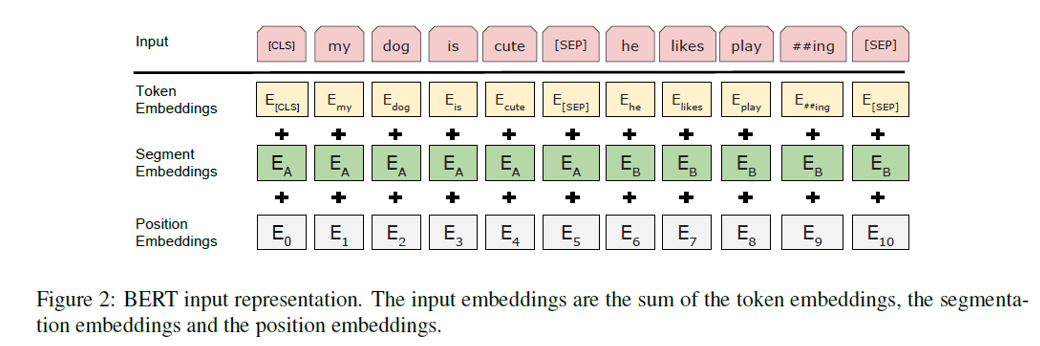

*BERT input representation: the input vector at each position is the sum of token, segment, and position embeddings. Source: Devlin et al. (2019), [*BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*](https://aclanthology.org/N19-1423/), Figure 2.*

## 5.3 What Is the Input to BERT Pre-training?
During original BERT pre-training, the model is trained on examples created from large text documents. The raw dataset is not necessarily stored as ready-made sentence pairs. Instead, preprocessing turns documents into training examples that usually contain two text segments:

```text
[CLS] segment A [SEP] segment B [SEP]
```

Each training example contains several arrays and labels:

| Component | Purpose |
|---|---|
| `input_ids` | Token IDs for `[CLS]`, the text tokens, `[SEP]`, and any padding |
| `token_type_ids` | 0 for segment A tokens and 1 for segment B tokens |
| `attention_mask` | 1 for real tokens and 0 for padding tokens |
| Masked language modeling labels | The original token IDs only at masked positions |
| Next sentence prediction label | Whether segment B really follows segment A |

For **Next Sentence Prediction (NSP)**, BERT creates two kinds of examples:

| Example type | How segment B is chosen | NSP label |
|---|---|---|
| Actual next segment | Segment B comes after segment A in the same document | `IsNext` |
| Random segment | Segment B is sampled from another document | `NotNext` |

At the same time, BERT applies **Masked Language Modeling (MLM)** by replacing some tokens with `[MASK]`, random tokens, or leaving them unchanged. The model must predict the original tokens at those selected positions.

Example training input:

```text
Original text pair:
Segment A: The movie was surprisingly good.
Segment B: I would watch it again.

Input to BERT and token_type_ids:
[CLS] the movie was [MASK] good . [SEP] i would watch it again . [SEP]
0     0   0     0   0      0    0 0     1 1     1     1  1     1 1

Training labels:
MLM label at [MASK] position = surprisingly
NSP label = IsNext
```

So, original BERT pre-training uses **segment pairs constructed from documents**, not only an already-prepared dataset of sentence pairs. Later, during fine-tuning, BERT can also accept a single sentence as `[CLS] sentence [SEP]`, with all token type IDs set to 0.


## 6. Pre-training BERT
### Task #1: **Masked Language Modeling (MLM)**
Masked Language Modeling (MLM) is BERT's self-supervised token prediction task. During pre-training, BERT sees a sentence or sentence pair with some tokens hidden, and it learns to recover the original tokens from both left and right context.

This is different from a traditional left-to-right language model. In a left-to-right model, the prediction at a position can only use previous tokens. In BERT, the prediction for a masked token can use the words before it and after it.

Example:

```text
Original:  the cat sat on the mat .
Input:     the cat sat on the [MASK] .
Target:    mat
```

#### How Tokens Are Selected for MLM
BERT selects about **15% of input tokens** as prediction targets. For those selected positions, the input is changed using this strategy:

| Replacement strategy | Percentage of selected tokens | Example input token | Why BERT uses it |
|---|---:|---|---|
| Replace with `[MASK]` | 80% | `mat` -> `[MASK]` | Gives BERT a clear missing-token prediction task |
| Replace with a random token | 10% | `mat` -> `tree` | Teaches BERT not to blindly trust the visible token and to use surrounding context |
| Leave unchanged | 10% | `mat` -> `mat` | Reduces the mismatch with fine-tuning, where inputs usually contain normal unmasked text |

The label is still the original token in all three cases. This prevents BERT from relying only on seeing `[MASK]`, because `[MASK]` does not appear in normal fine-tuning inputs.

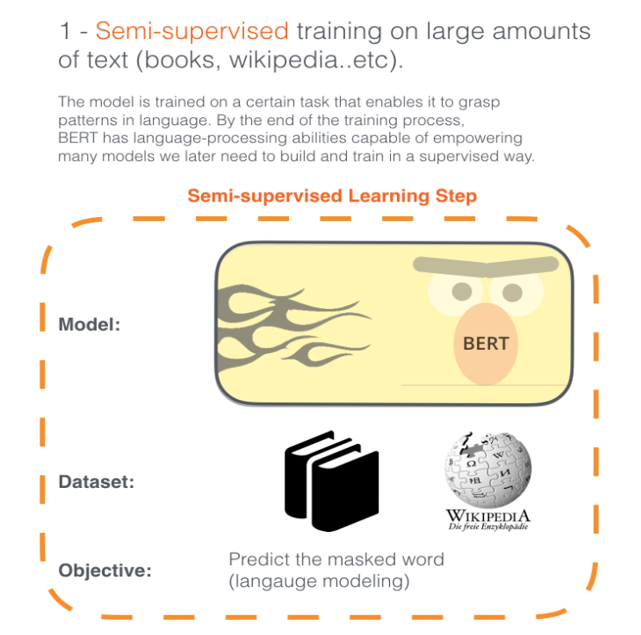

*Step 1: pre-training on unlabeled text (the original BERT used BooksCorpus and English Wikipedia). Source: Jay Alammar, [*The Illustrated BERT, ELMo, and co.*](https://jalammar.github.io/illustrated-bert/).*

#### Step-by-Step MLM Prediction
1. **Tokenization and input embeddings:** The tokenizer converts text into WordPiece token IDs. BERT forms each input vector by adding token, segment, and position embeddings.
2. **Contextual encoding:** The Transformer encoder lets every token attend to the other tokens, so the hidden vector at `[MASK]` contains information from the full sentence.
3. **Vocabulary prediction:** The MLM prediction head maps the hidden vector at each selected position to a vocabulary-sized vector of logits.
4. **Softmax and loss:** Softmax converts logits into token probabilities. Cross-entropy loss compares the predicted distribution with the original masked token.

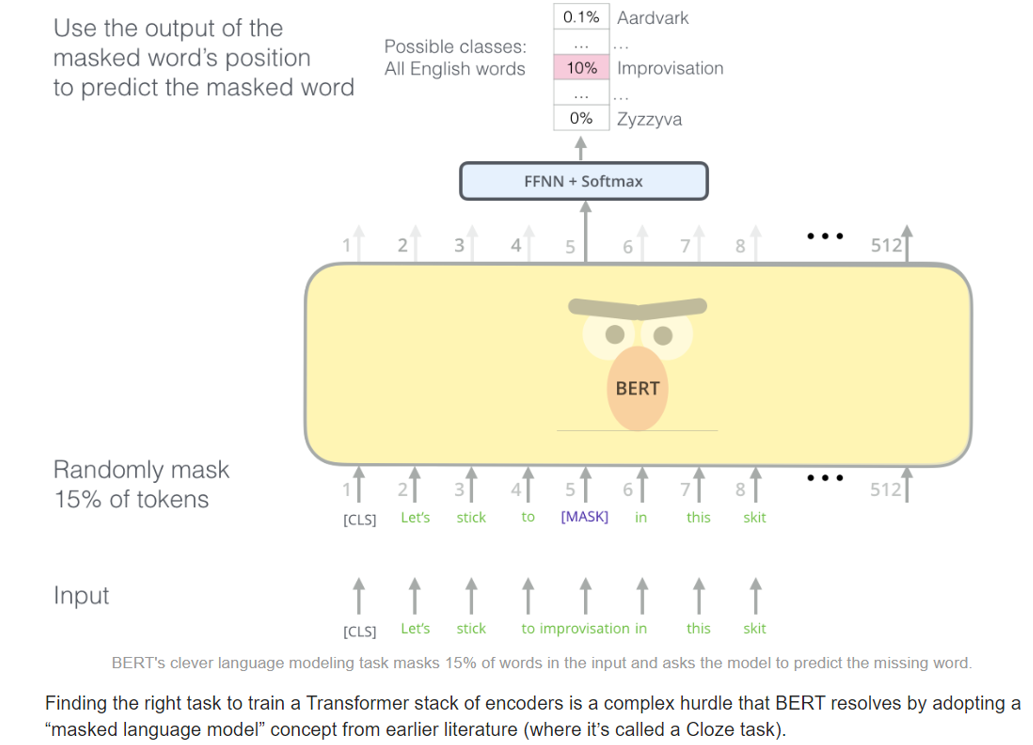

*Masked language modeling: the output vector at the masked position is mapped to scores over the whole vocabulary. The probabilities shown are illustrative. Source: Jay Alammar, [*The Illustrated BERT, ELMo, and co.*](https://jalammar.github.io/illustrated-bert/).*

The notebook [BERT pre-training: MLM and NSP](bert_mlm_nsp.ipynb) runs these steps on the pretrained model. It shows why masking is necessary, how the inputs and `-100` labels are built, the tensor shapes, and what the MLM head predicts.


### Task #2: **Next Sentence Prediction (NSP)**
In Next Sentence Prediction, BERT learns whether two text segments are related in order. This is different from MLM: **MLM predicts missing tokens**, while **NSP predicts the relationship between two segments**.

Each NSP training example is formatted as:

```text
[CLS] sentence A [SEP] sentence B [SEP]
```

BERT receives **segment embeddings** so it can distinguish sentence A from sentence B. Tokens from sentence A usually receive token type ID `0`, while tokens from sentence B receive token type ID `1`.

| Example type | How sentence B is chosen | NSP label |
|---|---|---|
| Actual next sentence | Sentence B really follows sentence A in the same document | `IsNext` |
| Random sentence | Sentence B is sampled from another document | `NotNext` |

During training, about **50%** of the pairs are `IsNext`, and about **50%** are `NotNext`.

The final hidden vector of the **[CLS]** token is passed to a small classification layer. This layer applies a softmax and predicts whether the input pair is `IsNext` or `NotNext`.

BERT trains **MLM and NSP at the same time**. The total pre-training loss combines the masked-token prediction loss and the next-sentence classification loss.

Why is NSP useful? It was designed to help BERT learn relationships between two pieces of text, which is important for tasks such as question answering, sentence-pair classification, and natural language inference.

Note: NSP was used in the **original BERT** pre-training objective, but some later BERT-style models, such as RoBERTa, removed NSP and used different pre-training choices. The notebook [BERT pre-training: MLM and NSP](bert_mlm_nsp.ipynb) scores sentence pairs with the pretrained NSP head and shows why this happened.

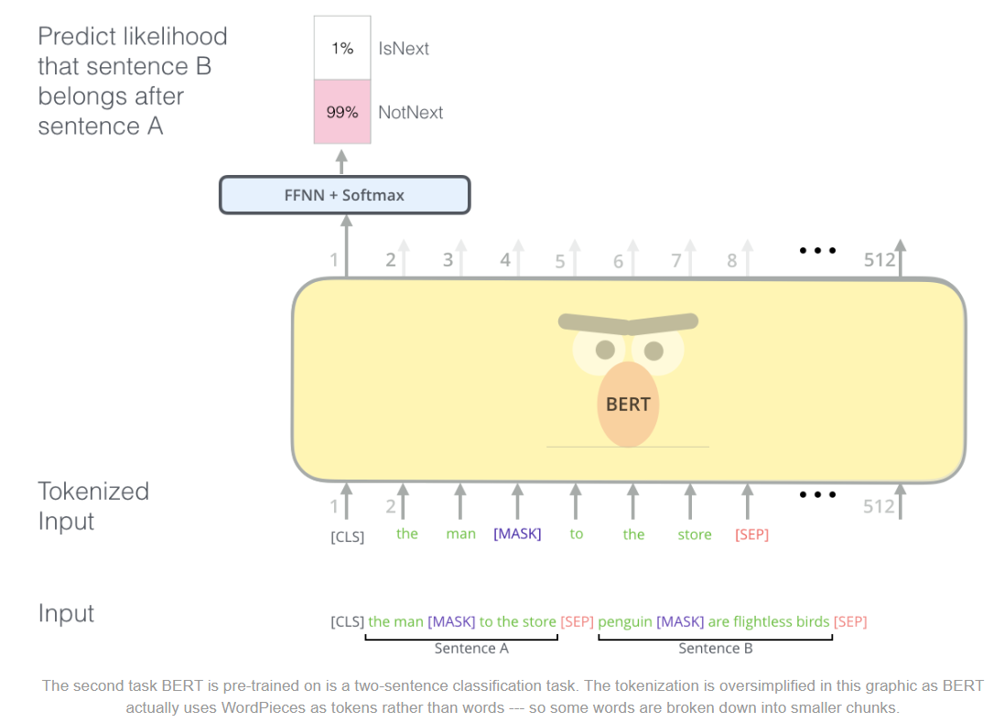

*Next sentence prediction from the `[CLS]` output vector. The probabilities shown are illustrative. Source: Jay Alammar, [*The Illustrated BERT, ELMo, and co.*](https://jalammar.github.io/illustrated-bert/).*

## 7. How to Use BERT (Fine-Tuning)
BERT can be fine-tuned for different tasks by adding **task-specific layers**:

- **Sentiment Analysis**: Add a classification layer to the **[CLS]** token output.
- **Question Answering (SQuAD)**: Learn two vectors marking the **start and end** of an answer in a text. Using BERT, a Q&A model can be trained by learning two extra vectors that mark the beginning and the end of the answer.
- **Named Entity Recognition (NER)**: Classify each token to identify entities (e.g., names, organizations, dates). Using BERT, a NER model can be trained by feeding the output vector of each token into a classification layer that predicts the NER label.

### Fine-Tuning Datasets for Common BERT Tasks
BERT is first pre-trained on large **unlabeled text**, but fine-tuning uses **labeled datasets** that match the downstream task. The input format and the labels change depending on what we want BERT to learn.

| Task | Common fine-tuning datasets | What the dataset contains | What BERT learns to predict |
|---|---|---|---|
| Text classification | GLUE tasks such as SST-2, MNLI, MRPC, QQP, CoLA; IMDb for sentiment | Sentences or sentence pairs with class labels | One label for the whole input, usually from the `[CLS]` representation |
| Question answering | SQuAD 1.1, SQuAD 2.0 | Question + passage pairs, with the answer span marked inside the passage | The start token and end token of the answer in the passage |
| Named Entity Recognition | CoNLL-2003, OntoNotes | Sentences where each token has an entity label | One label per token, such as `B-PER`, `I-PER`, `B-ORG`, or `O` |

Examples:

```text
Classification:
Input:  "This movie was surprisingly good."
Label:  Positive

Question Answering:
Question: "Who developed BERT?"
Passage:  "BERT was developed by researchers at Google AI Language."
Label:    answer starts at "Google" and ends at "Language"

Named Entity Recognition:
Tokens:  Sundar  Pichai  works  at  Google
Labels:  B-PER   I-PER   O      O   B-ORG
```

So, BERT fine-tuning is not done with one universal dataset format. Each downstream task provides its own supervised signal: sentence-level labels for classification, span labels for extractive question answering, and token-level labels for NER.

### Recommended Hyperparameters for Fine-Tuning:
| Hyperparameter     | Recommended Values |
|--------------------|-------------------|
| **Batch size**    | 16, 32            |
| **Learning rate** (Adam) | 5e-5, 3e-5, 2e-5 |
| **Epochs**        | 2, 3, 4           |

BERT’s fine-tuning process has been optimized to achieve **state-of-the-art** results across multiple NLP benchmarks.

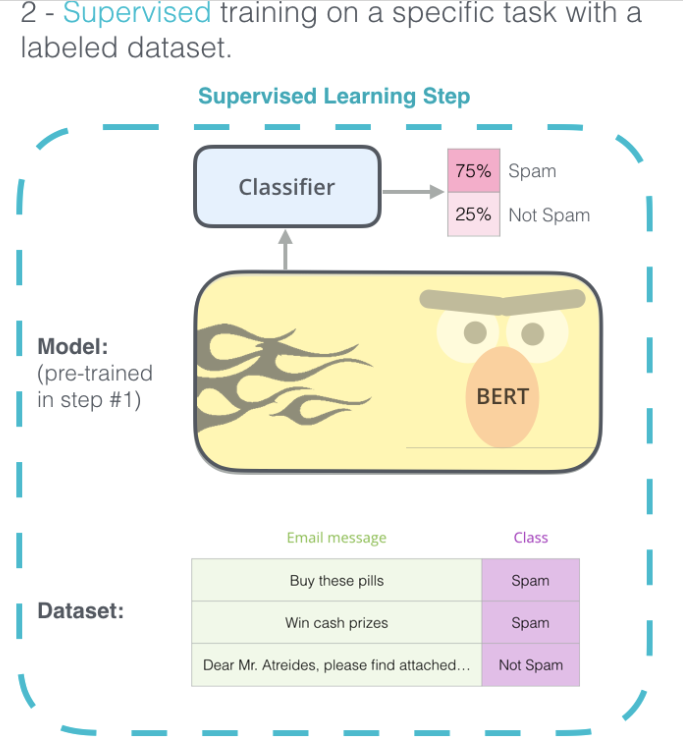

*Step 2: supervised fine-tuning, here with a spam classifier on top of the pre-trained model. Source: Jay Alammar, [*The Illustrated BERT, ELMo, and co.*](https://jalammar.github.io/illustrated-bert/).*

## 8. BERT Models in Hugging Face
In Hugging Face Transformers, it is useful to distinguish the **base BERT encoder** from **task-specific BERT models**.

The base encoder is usually loaded as:

```python
from transformers import BertModel

model = BertModel.from_pretrained("bert-base-uncased")
```

`BertModel` returns contextual representations rather than final task predictions. Its most important output is:

```text
last_hidden_state shape = (batch_size, sequence_length, hidden_size)
```

This means every input token receives one contextual vector. These vectors can be used directly as features, or a new prediction layer can be added for a custom task.

Task-specific Hugging Face classes add a prediction head on top of the same BERT encoder:

| Hugging Face class | What is added on top of BERT? | Typical use |
|---|---|---|
| `BertModel` | No task head; returns hidden states | Feature extraction or custom models |
| `BertForSequenceClassification` | Classification head over the sequence representation, often based on `[CLS]` | Sentiment analysis, topic classification |
| `BertForTokenClassification` | Classification head applied to each token vector | Named entity recognition, part-of-speech tagging |
| `BertForQuestionAnswering` | Two token-level heads for answer start and end positions | Extractive question answering |
| `BertForMaskedLM` | Masked language modeling head that predicts vocabulary tokens | MLM pre-training or masked-token prediction |

Conceptually, these models follow the same pattern:

```text
input tokens -> BERT encoder -> contextual vectors -> task-specific head -> task prediction
```

During fine-tuning, the task head is trained for the target task, and the BERT encoder weights are usually updated as well. This is why the same pretrained BERT checkpoint can be adapted to classification, NER, question answering, and other NLP tasks.

One important distinction: `BertForMaskedLM` is the model form used for BERT's pre-training objective, while classes such as `BertForSequenceClassification`, `BertForTokenClassification`, and `BertForQuestionAnswering` are commonly used for downstream fine-tuning tasks.


## 9. How BERT Works for Question Answering
BERT is commonly used for **extractive question answering**. In extractive QA, the model does not generate a new answer sentence from scratch. Instead, it selects the answer as a span of tokens from a given passage.

For example:

```text
Question: What is the capital of France?
Passage:  France is a country in Europe. Its capital is Paris.
```

The tokenizer combines the question and passage into one BERT input:

```text
[CLS] what is the capital of france ? [SEP] france is a country in europe . its capital is paris . [SEP]
```

The question tokens usually receive token type ID 0, and the passage tokens receive token type ID 1:

```text
[CLS] question tokens [SEP] passage tokens [SEP]
  0        0           0        1       1
```

BERT then produces one contextual vector for every token:

```text
last_hidden_state shape = (batch_size, sequence_length, hidden_size)
```

A question-answering head is added on top of these token vectors. It gives each token two scores:

| Score | Meaning |
|---|---|
| **Start score** | How likely this token is to be the first token of the answer |
| **End score** | How likely this token is to be the last token of the answer |

For the passage above, the highest start and end scores should both point to `paris`:

```text
Answer span: Paris
```

For a longer answer, BERT predicts a start token and an end token:

```text
Question: Where did the cat sit?
Passage:  The cat sat on the red mat near the window.

Predicted start token: red
Predicted end token:   mat
Answer span: red mat
```

The full flow is:

```text
question + passage
      ↓
BERT encoder
      ↓
contextual vector for each token
      ↓
start-position head + end-position head
      ↓
extract answer span from the passage
```

This is why BERT can answer questions without a decoder. It is not writing the answer word by word like a generative model. It is pointing to the most likely answer span inside the provided passage.


## 10. How BERT Works for Named Entity Recognition
Named Entity Recognition (NER) is usually framed as a **token classification** task. Instead of producing one label for the whole sentence, BERT predicts one label for each token.

For example:

```text
Sentence: Sundar Pichai works at Google in California.
```

A typical NER model may assign labels like:

```text
Sundar      B-PER
Pichai      I-PER
works       O
at          O
Google      B-ORG
in          O
California  B-LOC
.           O
```

Here, `PER` means person, `ORG` means organization, `LOC` means location, and `O` means the token is not part of a named entity. The `B-` and `I-` prefixes mark the **beginning** and **inside** of a multi-token entity.

The input still follows the normal BERT format:

```text
[CLS] sundar pichai works at google in california . [SEP]
```

BERT produces one contextual vector for every token:

```text
last_hidden_state shape = (batch_size, sequence_length, hidden_size)
```

For NER, a token-classification head is applied to each token vector:

```text
contextual token vector -> NER classification head -> label scores
```

If there are 7 possible NER labels, the output shape is:

```text
(batch_size, sequence_length, num_labels)
```

Each token receives a probability distribution over labels such as `B-PER`, `I-PER`, `B-ORG`, `B-LOC`, and `O`.

| Token | BERT uses context to decide | Example label |
|---|---|---|
| `sundar` | This token begins a person's name | `B-PER` |
| `pichai` | This token continues the same person's name | `I-PER` |
| `google` | This token refers to an organization | `B-ORG` |
| `california` | This token refers to a location | `B-LOC` |

The full flow is:

```text
sentence
   ↓
tokenizer
   ↓
BERT encoder
   ↓
contextual vector for each token
   ↓
token-classification head
   ↓
NER label for each token
```

A practical detail is that BERT uses WordPiece tokenization, so one word can split into multiple subword tokens. For example, an uncommon word may become:

```text
playingfield -> playing ##field
```

In NER training, labels are usually aligned carefully with these subword tokens. A common approach is to label the first subword and either copy the label to later subwords or ignore later subwords in the loss. The important idea is that BERT makes predictions at the token/subword level, and the final word-level entity labels are reconstructed from those predictions.


## 11. Using BERT Without Fine-tuning: Hidden States as Features
Fine-tuning is not the only way to use BERT. In the **feature-based** approach, BERT's weights stay frozen, and the hidden vectors from one or more encoder layers are passed as fixed features to a separate task model. Every layer produces a vector for every token, so we must choose which layer, or which combination of layers, to use.

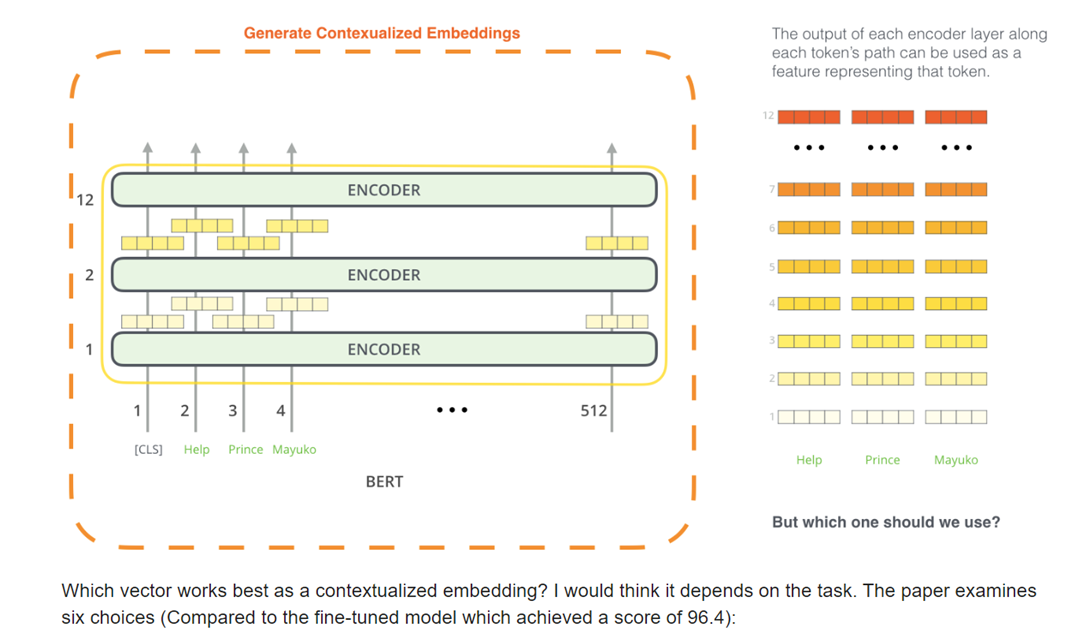

*Each of the 12 encoder layers produces a vector per token; any of them can serve as a feature. Source: Jay Alammar, [*The Illustrated BERT, ELMo, and co.*](https://jalammar.github.io/illustrated-bert/).*

The BERT paper compared these choices on CoNLL-2003 named entity recognition, using BERTBASE features as input to a separate two-layer BiLSTM and reporting development-set F1:

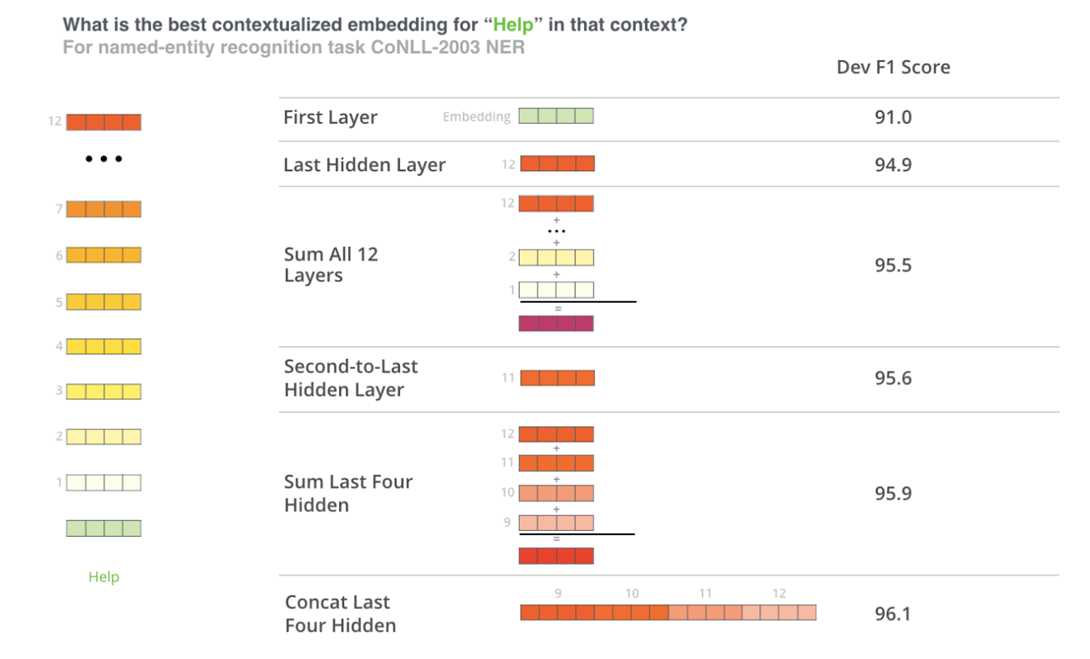

*Development-set F1 on CoNLL-2003 NER for different feature choices. The numbers are from Devlin et al. (2019), [*BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*](https://aclanthology.org/N19-1423/), Table 7, where the layer sums are weighted sums; figure by Jay Alammar, [*The Illustrated BERT, ELMo, and co.*](https://jalammar.github.io/illustrated-bert/).*

Interpretation: later layers give better features than the input embeddings (91.0), and combining the last four layers (96.1) comes within 0.3 F1 of fine-tuning the whole model (96.4). These are the paper's reported results; this notebook does not reproduce them.